In [11]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [12]:
df = pd.read_csv('cleaned_deceptive-opinion.csv')
df.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,stayed one night getaway family thursday. trip...
1,truthful,hyatt,positive,TripAdvisor,triple rate upgrade view room less $200 also i...
2,truthful,hyatt,positive,TripAdvisor,comes little late finally catching reviews pas...
3,truthful,omni,positive,TripAdvisor,omni chicago really delivers fronts spaciousne...
4,truthful,hyatt,positive,TripAdvisor,asked high floor away elevator got. room pleas...


In [13]:
df['label'] = df['deceptive'].map({'deceptive': 1, 'truthful': 0})
X = df['text']
y = df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
tfidf = joblib.load('tfidf_vectorizer.pkl') 
X_train_tfidf = tfidf.transform(X_train)     
X_test_tfidf  = tfidf.transform(X_test)


In [16]:
lr_model = LogisticRegression(max_iter=10000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

In [17]:
lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)
lr_cv   = cross_val_score(lr_model, X_train_tfidf, y_train, cv=5, scoring='accuracy').mean()

print(f"  Accuracy : {lr_acc:.4f}")
print(f"  Precision: {lr_prec:.4f}")
print(f"  Recall   : {lr_rec:.4f}")
print(f"  F1-Score : {lr_f1:.4f}")
print(f"  CV Acc (5-fold): {lr_cv:.4f}")
print("\nClassification Report:\n", classification_report(y_test, lr_pred, target_names=['Truthful', 'Deceptive']))

  Accuracy : 0.8875
  Precision: 0.8780
  Recall   : 0.9000
  F1-Score : 0.8889
  CV Acc (5-fold): 0.8867

Classification Report:
               precision    recall  f1-score   support

    Truthful       0.90      0.88      0.89       160
   Deceptive       0.88      0.90      0.89       160

    accuracy                           0.89       320
   macro avg       0.89      0.89      0.89       320
weighted avg       0.89      0.89      0.89       320



In [18]:
joblib.dump(lr_model, 'lr_model.pkl')

['lr_model.pkl']

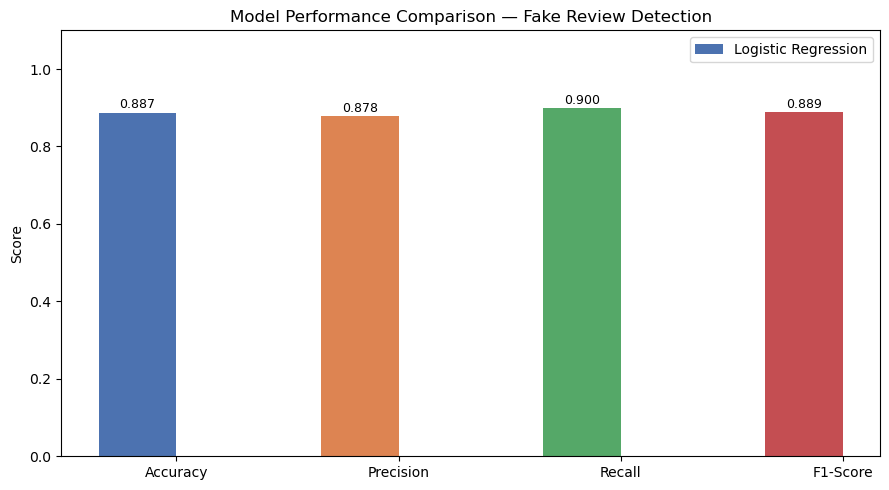

In [19]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [lr_acc, lr_prec, lr_rec, lr_f1]
x = np.arange(len(metrics_names))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Fake Review Detection')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.legend()
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('comparison_bar.png', dpi=150)
plt.show()

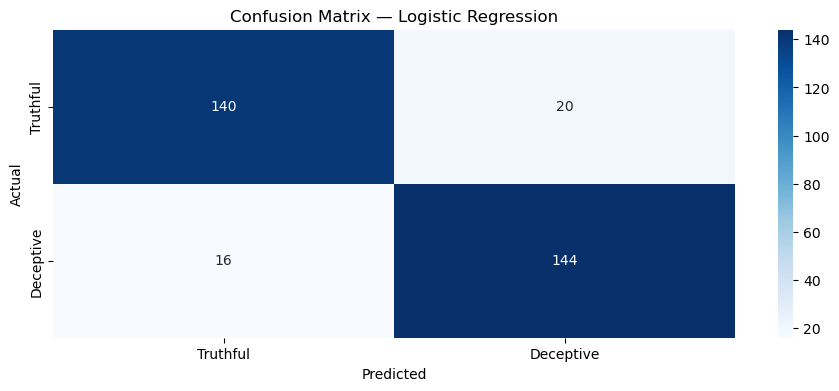

In [20]:
fig, ax = plt.subplots(figsize=(11, 4))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Truthful', 'Deceptive'],
            yticklabels=['Truthful', 'Deceptive'])
ax.set_title('Confusion Matrix — Logistic Regression')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()